**-----------------------------------------------Applying Custom CNN on MNIST Digits dataset--------------------------------------------------------**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn

In [ ]:
import tensorflow as tf
import keras.datasets.mnist as digits_mnist

Task 1: Load and Prepare the MNIST Dataset

● Use keras.datasets.mnist or download MNIST manually.

● Normalize image pixel values to be between 0 and 1.

● Flatten the label set into one-hot encoded vectors.


In [ ]:
(X_train,y_train),(X_test,y_test) = digits_mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
def simple_preprocessing(X,y):
    X_processed = X.astype('float') / 255

    X_processed = X_processed.reshape(-1,28,28,1)

    y_processed = to_categorical(y,10)

    return X_processed, y_processed

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
X_train_processed, y_train_processed = simple_preprocessing(X_train, y_train)
X_test_processed, y_test_processed = simple_preprocessing(X_test, y_test)


print("Processed training data shape:", X_train_processed.shape)
print("Processed training labels shape:", y_train_processed.shape)
print("Processed test data shape:", X_test_processed.shape)
print("Processed test labels shape:", y_test_processed.shape)

Processed training data shape: (60000, 28, 28, 1)
Processed training labels shape: (60000, 10)
Processed test data shape: (10000, 28, 28, 1)
Processed test labels shape: (10000, 10)


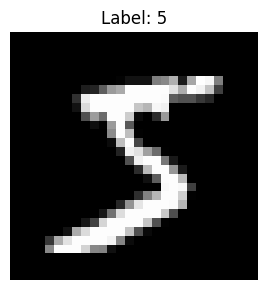

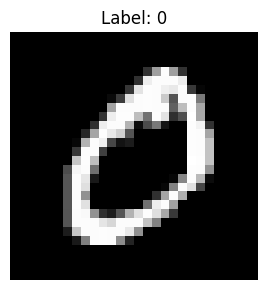

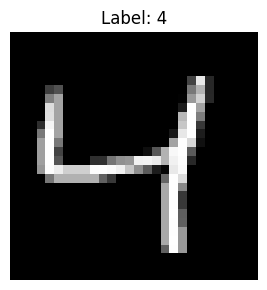

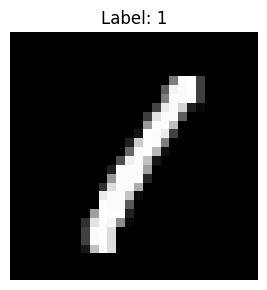

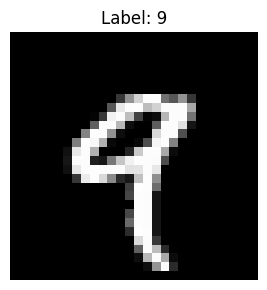

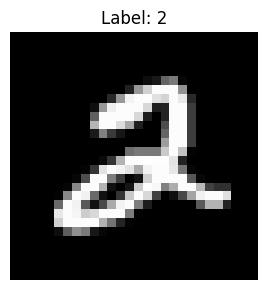

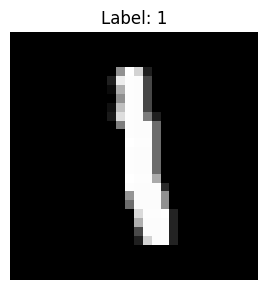

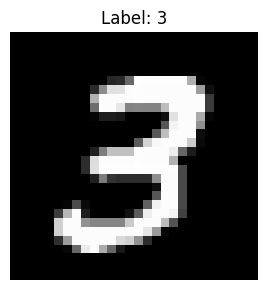

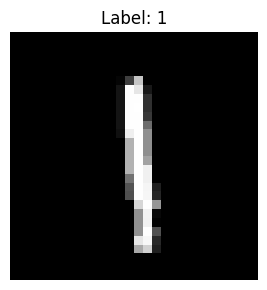

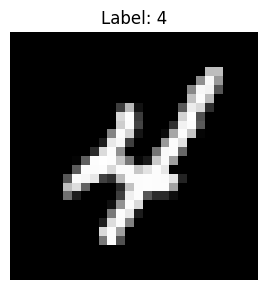

In [ ]:
for i in range(10):
    plt.figure(figsize=(4, 3))
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


Implement the Convolution Layer

● Use NumPy to implement a basic 2D convolution operation (no padding, stride = 1).

● Create a method convolve(image, kernel) that handles one channel.

● Use filters with random weights

In [ ]:
def convolve2D(image,kernal,padding=0,stride=1):
    h, w = image.shape
    kh, kw = kernal.shape
    oh = (h - kh) // stride + 1
    ow = (w - kw) // stride + 1
    output = np.zeros((oh,ow))

    for i in range(0,oh):
      for j in range(0,ow):
        region = image[i*stride : i*stride + kh, j*stride : j*stride + kw]
        output[i,j] = np.sum(region * kernal)


    return output



Task 3: Implement ReLU Activation

● Define a relu(x) function that sets all negative values to zero.

● Apply ReLU after each convolution

In [ ]:
def relu(Z):
  return np.maximum(0,Z)

In [ ]:
Z = np.array([-3, -1, 0, 2, 5])
A = relu(Z)
print(A)

[0 0 0 2 5]


Task 4: Implement Max Pooling Layer

● Define a method max_pool(image, size=2, stride=2).

● Reduce each feature map using non-overlapping windows

In [ ]:
def max_pool(image,size=2,stride=2):
  h, w = image.shape
  oh = (h - size) // stride + 1
  ow = (w - size) // stride + 1
  output = np.zeros((oh,ow))

  for i in range(0,oh):
    for j in range(0,ow):
      region = image[i*stride:i*stride + size , j*stride:j*stride + size]
      output[i,j] = np.max(region)

  return output

Task 5: Implement the Fully Connected Layer

● Flatten the output from the last pooling layer.

● Manually initialize weight matrix and bias vector.

● Perform dot product with weights + bias.


| Concept                 | Why It Matters                                                               |
| ----------------------- | ---------------------------------------------------------------------------- |
| **Weights in FC layer** | Every input connects to every output: `inputs × outputs`                     |
| **Flattening**          | Required to transform multi-dimensional data into 1D vector for dense layers |


In [ ]:
def fully_connected_layer(pool_output, n_output=10):
    flatten = np.array([item for row in pool_output for item in row])

    input_size = flatten.shape[0]

    np.random.seed(42)

    weights = np.random.randn(n_output,input_size) * 0.01
    bias = np.random.randn(n_output) * 0.01

    output = np.dot(weights,flatten) + bias

    return output




In [ ]:
array_2d = [[2,3,4],[1,3,2],[3,1,5]]


flat = [item for row in array_2d for item in row]
flat

[2, 3, 4, 1, 3, 2, 3, 1, 5]

In [ ]:
flatten1 = []
for row in array_2d:
  for item in row:
    flatten1.append(item)


flatten1

[2, 3, 4, 1, 3, 2, 3, 1, 5]

Task 6: Implement Softmax and Loss Function

● Write a softmax function to convert outputs into probabilities.

● Implement cross-entropy loss function.

In [ ]:
def softmax(logits):
    exps = np.exp(logits - np.max(logits))  # stability trick to avoid overflow
    return exps / np.sum(exps)

In [ ]:
def cross_entropy_loss(predicted_probs, true_labels):
    # To prevent log(0), clip predicted_probs to a small value
    predicted_probs = np.clip(predicted_probs, 1e-12, 1.0)
    return -np.sum(true_labels * np.log(predicted_probs))


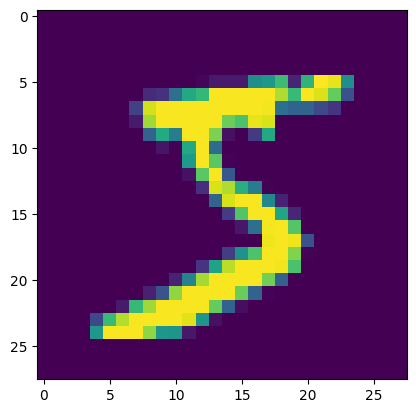

In [ ]:
plt.imshow(X_train_processed[0])

Performing 1 forward pass and checking the prediction.

In [ ]:
# Let's pick one sample
sample_image = X_train_processed[0].squeeze()   # shape (28, 28)
sample_label = y_train_processed[0]             # one-hot encoded (10,)

# # Step 1: Convolution

# np.random.seed(0)

# kernel = np.random.randn(3, 3)  # random 3x3 filter
kernel = np.array([[ -1,  0,  1],
                    [ -2,  0,  2],
                    [ -1,  0,  1]])
conv_output = convolve2D(sample_image, kernel)

# Step 2: ReLU
relu_output = relu(conv_output)

# Step 3: Max Pooling
pooled_output = max_pool(relu_output, size=2, stride=2)

# Step 4: Fully Connected Layer
fc_output = fully_connected_layer(pooled_output, n_output=10)

# Step 5: Softmax
probabilities = softmax(fc_output)

# Step 6: Cross-Entropy Loss
loss = cross_entropy_loss(probabilities, sample_label)

# Display the results
print("Final probabilities:", probabilities)
print("True label (one-hot):", sample_label)
print("Cross-entropy loss:", loss)


# Predict the class with highest probability
predicted_class = np.argmax(probabilities)

# Get the true class from one-hot encoded label
true_class = np.argmax(sample_label)

# Print prediction result
print(f"Predicted class: {predicted_class}")
print(f"True class: {true_class}")

if predicted_class == true_class:
    print("✅ Correctly classified!")
else:
    print("❌ Incorrectly classified.")



Final probabilities: [0.086623   0.11591289 0.09584663 0.10796968 0.09603588 0.11635424
 0.10181901 0.08780298 0.11098158 0.08065411]
True label (one-hot): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Cross-entropy loss: 2.1511159161864035
Predicted class: 5
True class: 5
✅ Correctly classified!


In [ ]:
num_samples = 100
corrects = 0  # Keep outside the loop

for i in range(num_samples):
    image = X_test_processed[i].squeeze()
    true_label = y_test_processed[i]  # one-hot encoded

    # Use fixed Sobel filter (edge detection)
    kernel = np.array([
        [-1,  0,  1],
        [-2,  0,  2],
        [-1,  0,  1]
    ])
    conv_output = convolve2D(image, kernel)
    relu_output = relu(conv_output)
    pooled_output = max_pool(relu_output, size=2, stride=2)
    output_logits = fully_connected_layer(pooled_output, n_output=10)
    predicted_probs = softmax(output_logits)

    predicted_label = np.argmax(predicted_probs)
    true_class = np.argmax(true_label)

    if predicted_label == true_class:
        corrects += 1

    # Print result for each sample
    print(f"Sample #{i + 1}")
    print(f"Predicted Label: {predicted_label}")
    print(f"True Label: {true_class}")
    print("✅ Correct!" if predicted_label == true_class else "❌ Wrong!")
    print("-" * 30)

# Final accuracy
accuracy = corrects / num_samples * 100
print(f"✅ Total Correct: {corrects} / {num_samples}")
print(f"📊 Accuracy: {accuracy:.2f}%")


Sample #1
Predicted Label: 5
True Label: 7
❌ Wrong!
------------------------------
Sample #2
Predicted Label: 5
True Label: 2
❌ Wrong!
------------------------------
Sample #3
Predicted Label: 5
True Label: 1
❌ Wrong!
------------------------------
Sample #4
Predicted Label: 7
True Label: 0
❌ Wrong!
------------------------------
Sample #5
Predicted Label: 8
True Label: 4
❌ Wrong!
------------------------------
Sample #6
Predicted Label: 5
True Label: 1
❌ Wrong!
------------------------------
Sample #7
Predicted Label: 2
True Label: 4
❌ Wrong!
------------------------------
Sample #8
Predicted Label: 6
True Label: 9
❌ Wrong!
------------------------------
Sample #9
Predicted Label: 4
True Label: 5
❌ Wrong!
------------------------------
Sample #10
Predicted Label: 4
True Label: 9
❌ Wrong!
------------------------------
Sample #11
Predicted Label: 8
True Label: 0
❌ Wrong!
------------------------------
Sample #12
Predicted Label: 8
True Label: 6
❌ Wrong!
------------------------------
S